In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_percentage_error, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 1. Tải dữ liệu
file_path = '/content/drive/My Drive/Colab Notebooks/supermarket_sales.csv'
df = pd.read_csv(file_path, parse_dates=['Order_Date']) #Chuyển đổi kiểu dữ liệu ngày
df = df.sort_values('Order_Date')
# 2.Đọc file chưa dữ liệu
print("==== THÔNG TIN DỮ LIỆU ====")

print(df.head())



Mounted at /content/drive
==== THÔNG TIN DỮ LIỆU ====
   Order_ID Order_Date Region Country      Sales_Rep    Team Customer_ID  \
0      4971 2021-01-01  North     USA      David Lee  Team C       C3971   
1      2347 2021-01-02  South  Brazil  Alice Johnson  Team B       C1347   
2      2588 2021-01-02  South  Brazil   Maria Garcia  Team C       C1588   
3      5092 2021-01-02   East   China   Priya Sharma  Team B       C4092   
4      1182 2021-01-02  North  Canada      David Lee  Team A       C0182   

  Customer_Segment Product_Category   Product_Name        Stage  Units_Sold  \
0        Corporate        Furniture   Office Chair          Won           6   
1              SME       Appliances  Microwave Max  Opportunity           2   
2           Retail       Appliances   Refrigerator  Opportunity           5   
3           Retail       Appliances  Microwave Max  Opportunity           5   
4           Retail      Electronics   Smartphone Z         Lost           0   

   Revenue  Ta

In [ ]:
# Tổng số dòng thiếu
missing_rows = df.isnull().any(axis=1).sum()
print("Tổng số dòng thiếu: ",missing_rows)
# Tổng số dòng trùng lặp
duplicate_rows = df.duplicated().sum()
print("Tổng số dòng trùng lặp: ",duplicate_rows)


Tổng số dòng thiếu:  0
Tổng số dòng trùng lặp:  0


In [ ]:
# Chuyển đổi Order_Date từ datetime sang numeric
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day

# Xóa các cột không cần thiết
# =============================
cols_to_drop = ["Order_ID", "Customer_ID", "Product_Name","Order_Date"]
df = df.drop(columns=cols_to_drop, errors='ignore')

# 3. Tiền xử lý dữ liệu và Chuẩn bị biến mục tiêu (Target Variable)
# Mã hóa biến mục tiêu 'Stage'
le = LabelEncoder()
df['Stage'] = le.fit_transform(df['Stage'])# =============================

#Kiểm tra dữ liệu
print(df.head())

  Region Country      Sales_Rep    Team Customer_Segment Product_Category  \
0  North     USA      David Lee  Team C        Corporate        Furniture   
1  South  Brazil  Alice Johnson  Team B              SME       Appliances   
2  South  Brazil   Maria Garcia  Team C           Retail       Appliances   
3   East   China   Priya Sharma  Team B           Retail       Appliances   
4  North  Canada      David Lee  Team A           Retail      Electronics   

   Stage  Units_Sold  Revenue  Target  Deal_Size  Order_Year  Order_Month  \
0      2           6     1662    1447       1665        2021            1   
1      1           2      464     875        928        2021            1   
2      1           5      132     277        264        2021            1   
3      1           5      610    1080       1220        2021            1   
4      0           0        0     854          0        2021            1   

   Order_Day  
0          1  
1          2  
2          2  
3          2  

In [ ]:
#Xóa các cột có khả năng gây data leakage
df = df.drop(columns=['Deal_Size','Revenue','Units_Sold'])

# Mã hóa Label Encoding cho các biến categorical
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# # Clip giá trị về khoảng [P1, P99] cho Units_Sold
# import numpy as np
# p1 = np.percentile(df['Units_Sold'], 1)
# p99 = np.percentile(df['Units_Sold'], 99)
# df['Units_Sold'] = df['Units_Sold'].clip(lower=p1, upper=p99)

# Kiểm tra
print("\n==== DỮ LIỆU SAU KHI LÀM SẠCH ====")
print(df.head())



==== DỮ LIỆU SAU KHI LÀM SẠCH ====
   Region  Country  Sales_Rep  Team  Customer_Segment  Product_Category  \
0       1        7          1     2                 0                 2   
1       2        1          0     1                 2                 0   
2       2        1          3     2                 1                 0   
3       0        3          4     1                 1                 0   
4       1        2          1     0                 1                 1   

   Stage  Target  Order_Year  Order_Month  Order_Day  
0      2    1447        2021            1          1  
1      1     875        2021            1          2  
2      1     277        2021            1          2  
3      1    1080        2021            1          2  
4      0     854        2021            1          2  


In [ ]:
# 6. Chia dữ liệu thành tập dữ liệu và kiểm tra

TARGET = "Stage"   # đổi theo cột mục tiêu của bạn

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Chia train - test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Đảm bảo kích thước dữ liệu đúng
print('Train set:', X_train.shape, y_train.shape)
print('Test set :', X_test.shape, y_test.shape)


Train set: (4000, 10) (4000,)
Test set : (1000, 10) (1000,)


In [ ]:
# 1. Scale features
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. Mã hóa target
# ===============================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 3. Thiết lập mô hình và Không gian tham số (Hyperparameters)
# ===============================
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Lưới tham số để tìm kiếm ngẫu nhiên
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True]
}

# 4. Thiết lập TimeSeriesSplit (5-fold)
# ===============================
tscv = TimeSeriesSplit(n_splits=5)

# 5. Cấu hình RandomizedSearchCV (50 thử nghiệm)
# ===============================
search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,           # 50 thử nghiệm ngẫu nhiên
    cv=tscv,             # Chia fold theo thời gian
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 6. Huấn luyện tìm bộ tham số tốt nhất
# ===============================
search.fit(X_train_scaled, y_train_enc)
best_model = search.best_estimator_

print(f"Best Params: {search.best_params_}")

# 7. Dự đoán trên tập Test bằng mô hình tốt nhất
# ===============================
y_pred_enc = best_model.predict(X_test_scaled)

# 8. Tính toán Metrics
# ===============================
f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")
f1_weighted = f1_score(y_test_enc, y_pred_enc, average="weighted")

print("-" * 30)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("-" * 30)
print("Accuracy:", accuracy_score(y_test_enc, y_pred_enc))
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_.astype(str)))
print(f"F1-score (macro)    : {f1_macro:.4f}")
print(f"F1-score (weighted) : {f1_weighted:.4f}")

# 9. Ma trận nhầm lẫn (Confusion Matrix)
# ===============================
cm = confusion_matrix(y_test_enc, y_pred_enc)

# In dạng bảng cho dễ đọc
cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

print("\nConfusion Matrix (table):")
print(cm_df)
    # Giả sử Deal_Size có trước...
    # Nhận định, đánh giá,...

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 3, 'bootstrap': True}
------------------------------
KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
------------------------------
Accuracy: 0.591

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.79      0.64       353
           1       0.61      0.88      0.72       315
           2       1.00      0.11      0.19       332

    accuracy                           0.59      1000
   macro avg       0.72      0.59      0.52      1000
weighted avg       0.72      0.59      0.52      1000

F1-score (macro)    : 0.5192
F1-score (weighted) : 0.5184

Confusion Matrix (table):
     0    1   2
0  280   73   0
1   39  276   0
2  197  100  35


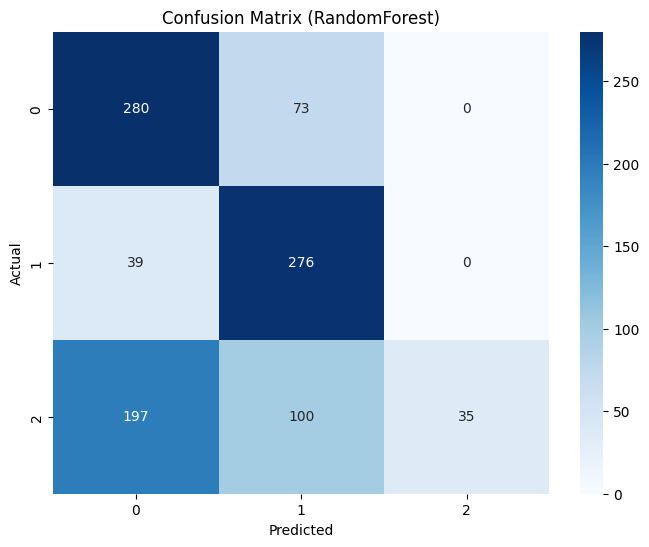

In [ ]:
# Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan
# ===============================
cm = confusion_matrix(y_test_enc, y_pred_enc)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # Hiện số liệu
    fmt="d",             # Định dạng số nguyên
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (RandomForest)")
plt.show()

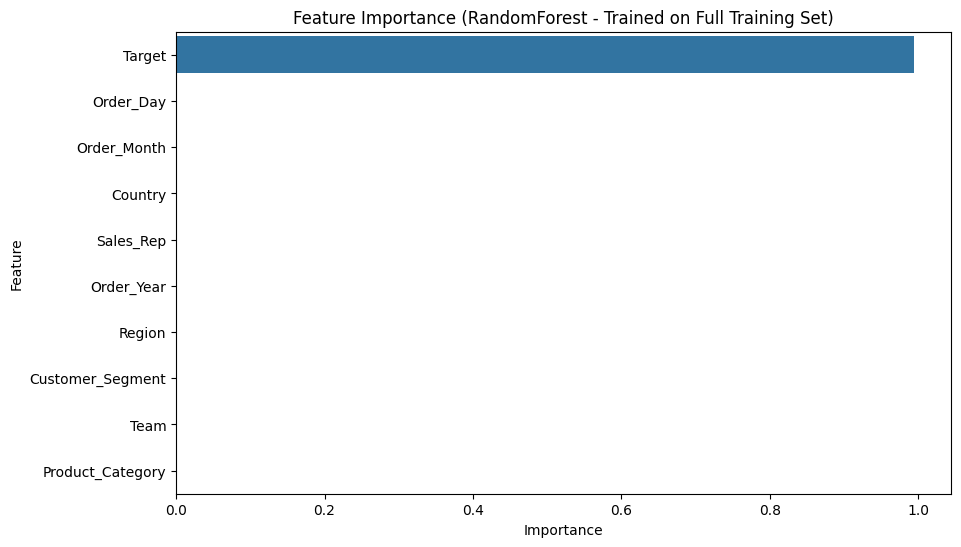

In [ ]:
# Lấy feature importance từ model đã train
importances = best_model.feature_importances_

# Tạo DataFrame
fi = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Vẽ Feature Importance
plt.figure(figsize=(10, max(6, 0.3 * len(fi))))
sns.barplot(data=fi, x="Importance", y="Feature")
plt.title("Feature Importance (RandomForest - Trained on Full Training Set)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# 1. Trích xuất độ quan trọng của các tính năng từ best_model
# ==========================================
importances = best_model.feature_importances_
feature_names = X_train.columns

# 2. Tạo DataFrame để quản lý
# ==========================================
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Lưu ra file CSV
# ==========================================
file_path_fi = "/content/drive/MyDrive/Colab Notebooks/feature_importance_RF.csv"
feature_importance_df.to_csv(file_path_fi, index=False)

print(f"Đã lưu file Feature Importance tại: {file_path_fi}")

# Hiển thị thử 10 biến quan trọng nhất
print("\nTop 10 Feature Importance:")
print(feature_importance_df.head(10))

Đã lưu file Feature Importance tại: /content/drive/MyDrive/Colab Notebooks/feature_importance_RF.csv

Top 10 Feature Importance:
            Feature  Importance
6            Target    0.994145
9         Order_Day    0.001742
8       Order_Month    0.001446
1           Country    0.000786
2         Sales_Rep    0.000689
7        Order_Year    0.000583
0            Region    0.000235
4  Customer_Segment    0.000163
3              Team    0.000112
5  Product_Category    0.000099


In [ ]:
# 1. Chuẩn bị dữ liệu cho tập TEST (Kèm dự đoán)
# ==========================================
X_test_df = X_test.copy()
X_test_df.reset_index(drop=True, inplace=True)

# Giải mã nhãn thực tế và nhãn dự đoán về dạng chữ gốc
y_actual_test = pd.Series(le.inverse_transform(y_test_enc), name="Actual")
y_pred_test   = pd.Series(le.inverse_transform(y_pred_enc), name="Predicted")

# Gộp tất cả features, giá trị thực tế và giá trị dự đoán
pred_test_df = pd.concat([X_test_df, y_actual_test, y_pred_test], axis=1)

# Lưu ra CSV cho tập Test
pred_test_df.to_csv("/content/drive/MyDrive/Colab Notebooks/preds_RandomForest_Test.csv", index=False)

print("Đã lưu thành công:")
print("- File Test (kèm dự đoán): preds_RandomForest_Test.csv")

Đã lưu thành công:
- File Test (kèm dự đoán): preds_RandomForest_Test.csv


In [ ]:
# 1. Kết nối với Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Cài đặt công cụ chuyển đổi nbconvert
!pip install nbconvert

# 3. Xuất file Notebook hiện tại sang HTML

!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/supermarket_sales(RandomForest).ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/supermarket_sales(RandomForest).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 394317 bytes to /content/drive/MyDrive/Colab Notebooks/supermarket_sales(RandomForest).html
